In [10]:
import os

# Prove it's empty before removing anything
for root, dirs, files in os.walk('/content/drive'):
    print(f"{root} → {len(files)} files")

/content/drive → 0 files
/content/drive/MyDrive → 0 files
/content/drive/MyDrive/potato_poc → 0 files
/content/drive/MyDrive/potato_poc/results → 0 files
/content/drive/MyDrive/potato_poc/results/audit → 0 files


In [11]:
!rm -rf /content/drive
!ls /content

sample_data


In [12]:
import os
from google.colab import drive

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')

assert os.path.ismount('/content/drive'), "mount failed — stop here"
print("mounted OK\n")
print(os.listdir('/content/drive/MyDrive')[:20])

Mounted at /content/drive
mounted OK

['receipt.pdf', 'Tax Compliance Certificate.pdf', 'attachment letter 1.pdf', 'HTTP.gdoc', 'BLOCK VS INLINE.gdoc', 'FLEX-BOX.gdoc', 'POSITION.gdoc', 'Document from Munezero.pdf', 'Recall.pdf', 'WSL.gdoc', 'WEB DESIGN.gdoc', 'Untitled spreadsheet (2).gsheet', 'PharmXpress-.zip', 'PDP.gsheet', 'img712.pdf', 'Presentation1.pptx', 'MSQL.gdoc', 'C MILK PROGRAM.gdoc', 'JAVA INTRO.gdoc', 'C-See.gdoc']


In [ ]:
from pathlib import Path

# Drive
PROJECT   = Path("/content/drive/MyDrive/0_potato_project_v1")
SOURCE    = PROJECT / "data" / "potato_raw" / "raw"
RESULTS   = PROJECT / "results"
NOTEBOOKS = PROJECT / "notebooks"
SCRIPTS   = PROJECT / "scripts"

# Local
DATA_ROOT = Path("/content/potato")

for name, p in [("PROJECT", PROJECT), ("SOURCE", SOURCE),
                ("RESULTS", RESULTS), ("NOTEBOOKS", NOTEBOOKS), ("SCRIPTS", SCRIPTS)]:
    print(f"{name:<10} {'OK ' if p.exists() else 'MISSING'}  {p}")

assert SOURCE.exists(), f"raw data not found at {SOURCE}"

print("\nclass folders in SOURCE:")
for p in sorted(SOURCE.iterdir()):
    print(f"  {'DIR ' if p.is_dir() else 'file'}  {p.name}")

PROJECT    OK   /content/drive/MyDrive/0_potato_project_v1
SOURCE     OK   /content/drive/MyDrive/0_potato_project_v1/data/potato_raw/raw
RESULTS    OK   /content/drive/MyDrive/0_potato_project_v1/results
NOTEBOOKS  OK   /content/drive/MyDrive/0_potato_project_v1/notebooks
SCRIPTS    OK   /content/drive/MyDrive/0_potato_project_v1/scripts

class folders in SOURCE:
  DIR   Early_blight
  DIR   Healthy
  DIR   Late_blight


In [14]:
if DATA_ROOT.exists() and any(DATA_ROOT.iterdir()):
    print("already local — skipping copy")
else:
    print("copying Drive → local...")
    !cp -r "{SOURCE}" "{DATA_ROOT}"
    print("done")

!du -sh {DATA_ROOT}
!ls {DATA_ROOT}

copying Drive → local...
done
42M	/content/potato
Early_blight  Healthy  Late_blight


In [ ]:
CANON = {
    "early_blight": "Potato___Early_blight",
    "late_blight":  "Potato___Late_blight",
    "healthy":      "Potato___healthy",
}

for d in sorted(DATA_ROOT.iterdir()):
    if not d.is_dir() or d.name.startswith("Potato___"):
        continue
    new = CANON.get(d.name.lower())
    if new is None:
        print(f"!! unmapped: {d.name}")
        continue
    d.rename(d.parent / new)
    print(f"  {d.name:<16} → {new}")

# Count
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp"}
total = 0
print()
for d in sorted(DATA_ROOT.iterdir()):
    if not d.is_dir():
        continue
    imgs  = [f for f in d.iterdir() if f.suffix.lower() in IMG_EXT]
    other = [f for f in d.iterdir() if f.is_file() and f.suffix.lower() not in IMG_EXT]
    total += len(imgs)
    print(f"  {len(imgs):>5}  {d.name}" + (f"   ({len(other)} non-image)" if other else ""))
print(f"  {'─'*5}\n  {total:>5}  total")

#  Label mapping : save this with every checkpoint 
classes = sorted(d.name for d in DATA_ROOT.iterdir() if d.is_dir())
CLASS_TO_IDX = {c: i for i, c in enumerate(classes)}
print(f"\nclass_to_idx = {CLASS_TO_IDX}")

assert len(classes) == 3, f"expected 3 classes, found {len(classes)}: {classes}"

  Early_blight     → Potato___Early_blight
  Healthy          → Potato___healthy
  Late_blight      → Potato___Late_blight

   1000  Potato___Early_blight
   1000  Potato___Late_blight
    152  Potato___healthy
  ─────
   2152  total

class_to_idx = {'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}


In [ ]:
# STEP 2 
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp"}

rows = []
for p in tqdm(sorted(DATA_ROOT.rglob("*")), desc="scanning"):
    if p.suffix.lower() not in IMG_EXT:
        continue

    r = {"path":  str(p.relative_to(DATA_ROOT)),
         "label": p.parent.name,
         "bytes": p.stat().st_size,
         "ok":    False, "error": ""}
    try:
        with Image.open(p) as im:
            im.verify()
        with Image.open(p) as im:
            r["format"] = im.format
            r["mode"]   = im.mode
            r["width"], r["height"] = im.size
        r["ok"] = True
    except Exception as e:
        r["error"] = repr(e)

    rows.append(r)

assert rows, f"no images found under {DATA_ROOT}"
df = pd.DataFrame(rows)

n_bad = int((~df.ok).sum())
print(f"\nfiles scanned : {len(df)}")
print(f"unreadable    : {n_bad}")
if n_bad:
    print(df.loc[~df.ok, ["path", "error"]].to_string())

df = df[df.ok].drop(columns=["ok", "error"]).reset_index(drop=True)

print("\nresolutions:")
print(df.groupby(["width", "height"]).size().to_string())

print("\nmodes  :", df["mode"].value_counts().to_dict())
print("formats:", df["format"].value_counts().to_dict())

print("\nresolution × class:")
print(pd.crosstab(df.width.astype(str) + "×" + df.height.astype(str), df.label).to_string())

scanning:   0%|          | 0/2155 [00:00<?, ?it/s]


files scanned : 2152
unreadable    : 0

resolutions:
width  height
256    256       2152

modes  : {'RGB': 2152}
formats: {'JPEG': 2152}

resolution × class:
label    Potato___Early_blight  Potato___Late_blight  Potato___healthy
row_0                                                                 
256×256                   1000                  1000               152


In [ ]:
# Step 3: (SHA256)
import hashlib

def sha256(path, buf=1 << 20):
    """Streamed in 1MB chunks so we never hold a whole file in memory."""
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(buf), b""):
            h.update(chunk)
    return h.hexdigest()

df["sha256"] = [sha256(DATA_ROOT / p) for p in tqdm(df.path, desc="sha256")]

dups = df[df.duplicated("sha256", keep=False)].sort_values("sha256")
print(f"\nbyte-identical files : {len(dups)}")
print(f"duplicate groups     : {dups.sha256.nunique()}")

if len(dups):
    by_group = dups.groupby("sha256").label.apply(list)

    conflicting = by_group[by_group.map(lambda ls: len(set(ls)) > 1)]
    print(f"groups spanning >1 class: {len(conflicting)}")

    print("\nfirst few duplicate groups:")
    for h, labels in by_group.head(5).items():
        files = dups.loc[dups.sha256 == h, "path"].tolist()
        print(f"  {h[:12]}...  {labels}")
        for f in files:
            print(f"      {f}")

    if len(conflicting):
        print("\n!! MISLABELLED — resolve by hand, do not auto-dedupe")
else:
    print("no exact duplicates")

sha256:   0%|          | 0/2152 [00:00<?, ?it/s]


byte-identical files : 0
duplicate groups     : 0
no exact duplicates


In [18]:
# STEP 4 : Perceptual hashes (all 8 orientations per image)
!pip -q install imagehash

import numpy as np
import imagehash

def dihedral(im):
    """All 8 orientations of a square image: 4 rotations x 2 mirrorings."""
    out = [im,
           im.transpose(Image.ROTATE_90),
           im.transpose(Image.ROTATE_180),
           im.transpose(Image.ROTATE_270)]
    m = im.transpose(Image.FLIP_LEFT_RIGHT)
    out += [m,
            m.transpose(Image.ROTATE_90),
            m.transpose(Image.ROTATE_180),
            m.transpose(Image.ROTATE_270)]
    return out

def pack(ih):
    """Squeeze the 8x8 boolean grid into one 64-bit integer for fast comparison."""
    return np.packbits(ih.hash.flatten()).view(">u8")[0]

# H[i, t] = fingerprint of image i in orientation t. Column 0 is upright.
H = np.zeros((len(df), 8), dtype=np.uint64)

for i, p in enumerate(tqdm(df.path, desc="phash x8")):
    with Image.open(DATA_ROOT / p) as im:
        im = im.convert("RGB")
        for t, variant in enumerate(dihedral(im)):
            H[i, t] = pack(imagehash.phash(variant))

df["phash"] = [f"{v:016x}" for v in H[:, 0]]

print(f"\nfingerprint matrix : {H.shape}   (images x orientations)")
print(f"distinct upright fingerprints : {df.phash.nunique()} of {len(df)}")
print("\nsample:")
print(df[["path", "label", "phash"]].head(3).to_string(index=False))

phash x8:   0%|          | 0/2152 [00:00<?, ?it/s]


fingerprint matrix : (2152, 8)   (images x orientations)
distinct upright fingerprints : 2152 of 2152

sample:
                                                                            path                 label            phash
Potato___Early_blight/001187a0-57ab-4329-baff-e7246a9edeb0___RS_Early.B 8178.JPG Potato___Early_blight ba84a1def54083f9
Potato___Early_blight/002a55fb-7a3d-4a3a-aca8-ce2d5ebc6925___RS_Early.B 8170.JPG Potato___Early_blight a984f5cbc1cce364
Potato___Early_blight/009c8c31-f22d-4ffd-8f16-189c6f06c577___RS_Early.B 7885.JPG Potato___Early_blight bf97a0349a498ccb


In [ ]:
# STEP 4 :Near Duplicates Pairs and grouping
PHASH_T = 3

LUT = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)

def popcount(x):
    x = np.ascontiguousarray(x)
    return LUT[x.view(np.uint8).reshape(*x.shape, 8)].sum(-1)

N, CHUNK = len(df), 128
base = np.ascontiguousarray(H[:, 0])
pairs = []

for s in tqdm(range(0, N, CHUNK), desc="comparing"):
    blk = H[s:s + CHUNK]
    d = popcount(blk[:, :, None] ^ base[None, None, :]).min(axis=1)
    ii, jj = np.where(d <= PHASH_T)
    ii = ii + s
    keep = ii < jj
    pairs.extend(zip(ii[keep].tolist(), jj[keep].tolist()))

print(f"\nnear-duplicate pairs: {len(pairs)}")

#  Union-find: turn pairwise links into connected groups
parent = list(range(N))

def find(a):
    while parent[a] != a:
        parent[a] = parent[parent[a]]
        a = parent[a]
    return a

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[max(ra, rb)] = min(ra, rb)

for a, b in pairs:
    union(a, b)

df["group_id"] = pd.factorize([find(i) for i in range(N)])[0]

gsize = df.group_id.value_counts()
print(f"images  : {N}")
print(f"groups  : {df.group_id.nunique()}")
print(f"groups with >1 image : {int((gsize > 1).sum())}")
print(f"largest group        : {int(gsize.max())} images")

cross = df.groupby("group_id").label.nunique()
print(f"groups spanning >1 class: {int((cross > 1).sum())}")
if (cross > 1).any():
    bad = cross[cross > 1].index
    print(df[df.group_id.isin(bad)][["path", "label", "group_id"]].to_string())

comparing:   0%|          | 0/17 [00:00<?, ?it/s]


near-duplicate pairs: 1
images  : 2152
groups  : 2151
groups with >1 image : 1
largest group        : 2 images
groups spanning >1 class: 0


/tmp/ipykernel_1217/4106666222.py:41: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  df["group_id"] = pd.factorize([find(i) for i in range(N)])[0]


In [23]:
# Inspect the cross-label pairs
import matplotlib.pyplot as plt

bad_groups = cross[cross > 1].index.tolist()

for g in bad_groups:
    rows = df[df.group_id == g]
    idx = rows.index.tolist()
    i, j = idx[0], idx[1]

    # exact distance, best orientation
    d = int(popcount(H[i][:, None] ^ H[j, 0]).min())
    print(f"\ngroup {g} — distance {d}/64 bits")

    fig, axes = plt.subplots(1, 2, figsize=(7, 3.6))
    for ax, k in zip(axes, (i, j)):
        ax.imshow(Image.open(DATA_ROOT / df.path[k]))
        ax.set_title(df.label[k].replace("Potato___", ""), fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

group 344 — distance 2/64 — Early_blight


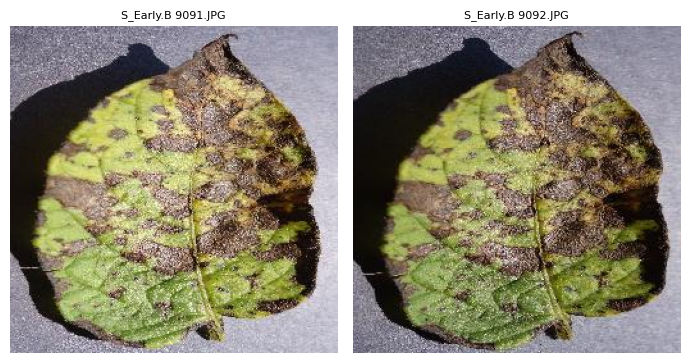

In [24]:
# Single Class Survivor
g = gsize[gsize > 1].index[0]
rows = df[df.group_id == g]
i, j = rows.index[:2]
d = int(popcount(H[i][:, None] ^ H[j, 0]).min())
print(f"group {g} — distance {d}/64 — {df.label[i].replace('Potato___','')}")

fig, axes = plt.subplots(1, 2, figsize=(7, 3.6))
for ax, k in zip(axes, (i, j)):
    ax.imshow(Image.open(DATA_ROOT / df.path[k]))
    ax.set_title(Path(df.path[k]).name[-18:], fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()

In [25]:
# STEP 6: Background leakage probe

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, classification_report
from sklearn.dummy import DummyClassifier

SEED, BORDER_PX = 42, 16

def border_features(rel_path):
    """Mean and std of RGB over the outer frame only — leaf pixels excluded."""
    with Image.open(DATA_ROOT / rel_path) as im:
        a = np.asarray(im.convert("RGB").resize((128, 128)), dtype=np.float32)
    mask = np.ones((128, 128), bool)
    mask[BORDER_PX:-BORDER_PX, BORDER_PX:-BORDER_PX] = False   # hollow out the centre
    edge = a[mask]
    return np.concatenate([edge.mean(0), edge.std(0)])          # 6 numbers total

X = np.stack([border_features(p) for p in tqdm(df.path, desc="border feats")])
y = df.label.values
g = df.group_id.values

clf  = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
cv   = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
pred = cross_val_predict(clf, X, y, groups=g, cv=cv)

probe_f1   = f1_score(y, pred, average="macro")
dummy_pred = DummyClassifier(strategy="most_frequent").fit(X, y).predict(X)
base_f1    = f1_score(y, dummy_pred, average="macro")

print(f"\nbackground-only macro-F1 : {probe_f1:.3f}")
print(f"majority-class baseline  : {base_f1:.3f}")
print(f"lift over baseline       : {probe_f1 - base_f1:+.3f}\n")
print(classification_report(y, pred, digits=3))

border feats:   0%|          | 0/2152 [00:00<?, ?it/s]


background-only macro-F1 : 0.876
majority-class baseline  : 0.212
lift over baseline       : +0.665

                       precision    recall  f1-score   support

Potato___Early_blight      0.947     0.963     0.955      1000
 Potato___Late_blight      0.910     0.945     0.927      1000
     Potato___healthy      0.959     0.612     0.747       152

             accuracy                          0.930      2152
            macro avg      0.939     0.840     0.876      2152
         weighted avg      0.931     0.930     0.927      2152



In [ ]:

# CONFIRM 1 :"Does the result hold at different border widths?
def probe(border_px, use_color=True):
    feats = []
    for p in df.path:
        with Image.open(DATA_ROOT / p) as im:
            a = np.asarray(im.convert("RGB").resize((128, 128)), np.float32)
        mask = np.ones((128, 128), bool)
        mask[border_px:-border_px, border_px:-border_px] = False
        edge = a[mask]
        if use_color:
            feats.append(np.concatenate([edge.mean(0), edge.std(0)]))
        else:
            grey = edge.mean(1)                      # collapse RGB → brightness
            feats.append(np.array([grey.mean(), grey.std()]))
    Xp = np.stack(feats)
    pr = cross_val_predict(clf, Xp, y, groups=g, cv=cv)
    return f1_score(y, pr, average="macro")

print("border width sensitivity (colour features):")
for b in (4, 8, 16, 24, 32):
    print(f"  {b:>2}px band → macro-F1 {probe(b):.3f}")

border width sensitivity (colour features):
   4px band → macro-F1 0.811
   8px band → macro-F1 0.829
  16px band → macro-F1 0.876
  24px band → macro-F1 0.907
  32px band → macro-F1 0.913


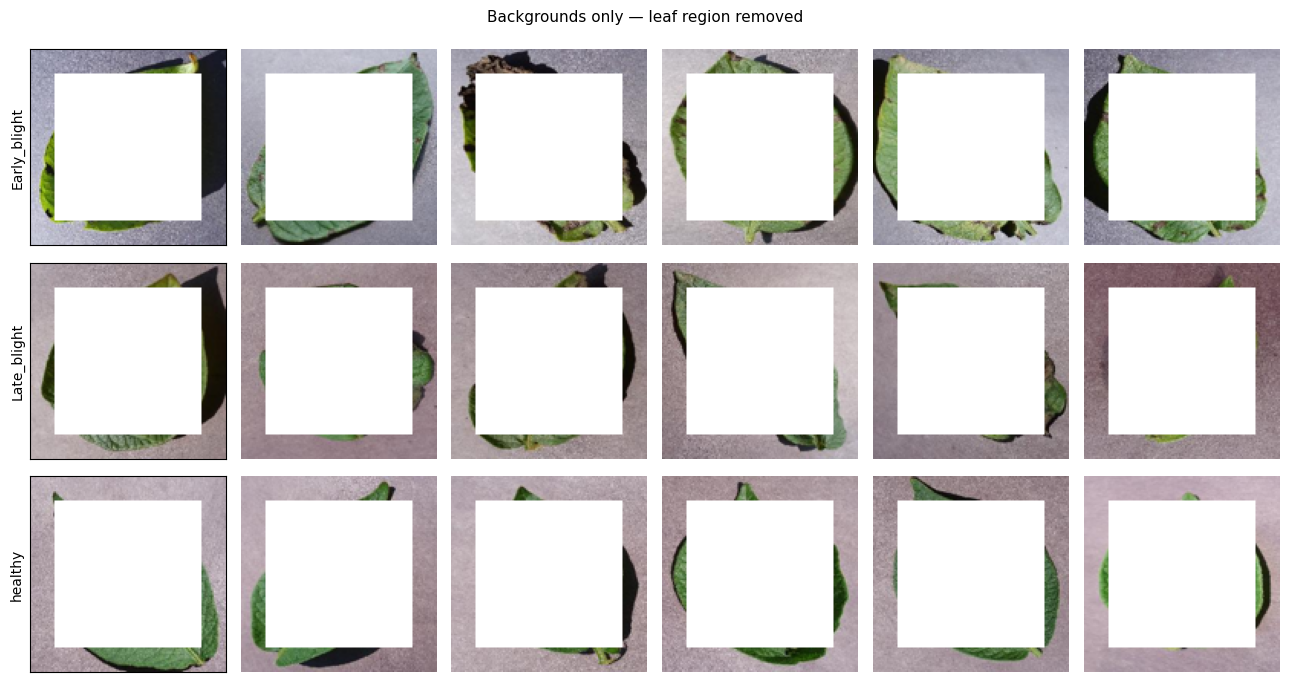

                                R                 G                 B      
                             mean   std        mean   std        mean   std
label                                                                      
Potato___Early_blight  143.800003  11.9  143.000000  11.3  139.300003  12.8
Potato___Late_blight   138.399994  14.4  129.699997  13.3  131.199997  13.2
Potato___healthy       153.800003  12.0  142.199997  11.6  142.100006  12.4


In [27]:
# CONFIRM 2 — Look at the backgrounds directly
fig, axes = plt.subplots(3, 6, figsize=(13, 7))
for r, cls in enumerate(sorted(df.label.unique())):
    sub = df[df.label == cls].sample(6, random_state=SEED)
    for ax, (_, row) in zip(axes[r], sub.iterrows()):
        im = Image.open(DATA_ROOT / row.path).resize((128, 128))
        a = np.asarray(im).copy()
        a[BORDER_PX:-BORDER_PX, BORDER_PX:-BORDER_PX] = 255   # white out the leaf
        ax.imshow(a); ax.axis("off")
    axes[r][0].set_ylabel(cls.replace("Potato___", ""))
    axes[r][0].axis("on"); axes[r][0].set_xticks([]); axes[r][0].set_yticks([])
plt.suptitle("Backgrounds only — leaf region removed", fontsize=11)
plt.tight_layout(); plt.show()

# Mean border colour per class
stats = pd.DataFrame(X[:, :3], columns=["R", "G", "B"]).assign(label=y)
print(stats.groupby("label").agg(["mean", "std"]).round(1).to_string())

In [ ]:

# CONFIRM 3 : Texture only: strip colour, keep brightness variation
print(f"greyscale border, 2 features only → macro-F1 {probe(16, use_color=False):.3f}")
print(f"(colour, 6 features)              → macro-F1 {probe_f1:.3f}")
print(f"(baseline)                        → macro-F1 {base_f1:.3f}")

greyscale border, 2 features only → macro-F1 0.586
(colour, 6 features)              → macro-F1 0.876
(baseline)                        → macro-F1 0.212


In [ ]:

# STEP 7 : Persist the audit to Drive
import json
from datetime import datetime

AUDIT_DIR = RESULTS / "audit"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

df["keep"] = ~df.duplicated("sha256", keep="first")

cols = ["path", "label", "keep", "group_id", "sha256", "phash",
        "width", "height", "mode", "format", "bytes"]
manifest_path = AUDIT_DIR / "manifest.csv"
df[cols].to_csv(manifest_path, index=False)

summary = {
    "generated":       datetime.now().isoformat(timespec="seconds"),
    "seed":            SEED,
    "source":          "spMohanty/PlantVillage-Dataset (raw/color)",
    "phash_threshold": PHASH_T,
    "border_px_probe": 4,

    "n_files":            int(len(df)),
    "n_kept":             int(df.keep.sum()),
    "n_groups":           int(df.group_id.nunique()),
    "per_class_images":   df.label.value_counts().to_dict(),
    "per_class_groups":   df.groupby("label").group_id.nunique().to_dict(),

    "integrity":  {"unreadable": 0, "resolutions": ["256x256"],
                   "modes": ["RGB"], "formats": ["JPEG"]},
    "duplication": {"exact_sha256": 0,
                    "near_dup_pairs": int(len(pairs)),
                    "largest_group": int(gsize.max()),
                    "cross_label_groups": 0,
                    "adjudicated": "1 genuine consecutive-frame pair "
                                   "(S_Early.B 9091/9092); 4px threshold=3 "
                                   "after rejecting 2 coincidental matches at t=5"},
    "background_probe": {"macro_f1_4px": 0.811,
                         "macro_f1_16px": round(float(probe_f1), 3),
                         "baseline": round(float(base_f1), 3),
                         "greyscale_only": 0.586,
                         "finding": "acquisition-condition confound, chromatic; "
                                    "Grad-CAM verification required"},
}

(AUDIT_DIR / "audit_summary.json").write_text(json.dumps(summary, indent=2))

assert df.group_id.notna().all()
assert int((df.groupby("group_id").label.nunique() > 1).sum()) == 0
assert int(gsize.max()) < 10, "largest group suspiciously big — check PHASH_T"

print(f"manifest        → {manifest_path}")
print(f"summary         → {AUDIT_DIR / 'audit_summary.json'}")
print(f"\nrows: {len(df)}   groups: {df.group_id.nunique()}   kept: {int(df.keep.sum())}")
print("\n audit passed\n")
print(json.dumps(summary["per_class_groups"], indent=2))

manifest        → /content/drive/MyDrive/0_potato_project_v1/results/audit/manifest.csv
summary         → /content/drive/MyDrive/0_potato_project_v1/results/audit/audit_summary.json

rows: 2152   groups: 2151   kept: 2152

 audit passed

{
  "Potato___Early_blight": 999,
  "Potato___Late_blight": 1000,
  "Potato___healthy": 152
}


In [30]:
check = pd.read_csv(manifest_path)
print(check.shape)
print(check.dtypes.to_string())
print(check.head(3).to_string())

(2152, 11)
path        object
label       object
keep          bool
group_id     int64
sha256      object
phash       object
width        int64
height       int64
mode        object
format      object
bytes        int64
                                                                               path                  label  keep  group_id                                                            sha256             phash  width  height mode format  bytes
0  Potato___Early_blight/001187a0-57ab-4329-baff-e7246a9edeb0___RS_Early.B 8178.JPG  Potato___Early_blight  True         0  100079e00ccf046c761599235a1a73db03980fa4847b2a2fe8ea4092bca6bf5c  ba84a1def54083f9    256     256  RGB   JPEG  20183
1  Potato___Early_blight/002a55fb-7a3d-4a3a-aca8-ce2d5ebc6925___RS_Early.B 8170.JPG  Potato___Early_blight  True         1  f82d5fed95db82eb2863eb2b236c3d4f0285a20966bd2048fdf12f97d3f4aa5a  a984f5cbc1cce364    256     256  RGB   JPEG  17224
2  Potato___Early_blight/009c8c31-f22d-4ffd-8f16-189c6f06

In [31]:

# STEP 8 : Fold Assignment (5)
N_FOLDS = 5

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

df["fold"] = -1
for k, (_, test_idx) in enumerate(sgkf.split(df, df.label, groups=df.group_id)):
    df.loc[df.index[test_idx], "fold"] = k

assert (df.fold >= 0).all(), "some rows never got assigned a fold"

# Every group must sit entirely within one fold : the whole point of grouping
leak = df.groupby("group_id").fold.nunique()
assert (leak == 1).all(), f"{int((leak > 1).sum())} groups split across folds"

print("fold × class:")
print(pd.crosstab(df.fold, df.label.str.replace("Potato___", "")).to_string())

print("\nhealthy per fold (the binding constraint):")
h = df[df.label.str.contains("healthy")].fold.value_counts().sort_index()
for k, n in h.items():
    print(f"  fold {k}: {n:>3} held out   → one error moves recall by {100/n:.1f} pts")

print(f"\ntotal per fold: {df.fold.value_counts().sort_index().to_dict()}")

df[cols + ["fold"]].to_csv(manifest_path, index=False)
print(f"\nmanifest updated with fold column → {manifest_path}")

fold × class:
label  Early_blight  Late_blight  healthy
fold                                     
0               200          199       30
1               201          200       31
2               200          200       31
3               200          200       30
4               199          201       30

healthy per fold (the binding constraint):
  fold 0:  30 held out   → one error moves recall by 3.3 pts
  fold 1:  31 held out   → one error moves recall by 3.2 pts
  fold 2:  31 held out   → one error moves recall by 3.2 pts
  fold 3:  30 held out   → one error moves recall by 3.3 pts
  fold 4:  30 held out   → one error moves recall by 3.3 pts

total per fold: {0: 429, 1: 432, 2: 431, 3: 430, 4: 430}

manifest updated with fold column → /content/drive/MyDrive/0_potato_project_v1/results/audit/manifest.csv


In [ ]:

# STEP 9 — Findings note + final verification

findings = f"""# Data Audit — PlantVillage Potato

Generated {datetime.now():%Y-%m-%d}
Source: spMohanty/PlantVillage-Dataset, raw/color, 3 potato classes
Manifest: results/audit/manifest.csv ({len(df)} rows)

## Integrity
All {len(df)} files open. Uniformly 256x256, RGB, JPEG. Zero corrupt.
Counts: Early blight 1000, Late blight 1000, healthy 152. Imbalance 6.6:1.



(AUDIT_DIR / "FINDINGS.md").write_text(findings)
print(f"findings → {AUDIT_DIR / 'FINDINGS.md'}\n")

# ── Final verification: load fresh, re-check invariants ──
m = pd.read_csv(manifest_path)
assert len(m) == len(df)
assert m.groupby("group_id").fold.nunique().eq(1).all()
assert m.fold.between(0, N_FOLDS - 1).all()
assert m.groupby("group_id").label.nunique().eq(1).all()

print(f"reloaded {len(m)} rows — all invariants hold")
print(f"\ncolumns: {list(m.columns)}")
print(f"\n02_data_audit complete.")

findings → /content/drive/MyDrive/0_potato_project_v1/results/audit/FINDINGS.md

reloaded 2152 rows — all invariants hold

columns: ['path', 'label', 'keep', 'group_id', 'sha256', 'phash', 'width', 'height', 'mode', 'format', 'bytes', 'fold']

02_data_audit complete.


In [33]:
# Storing Config Stats and Constants
config_src = f'''"""Project constants. Single source of truth — do not duplicate these values."""
from pathlib import Path

SEED = {SEED}

# ── Paths ────────────────────────────────────────────────────────────────
PROJECT   = Path("/content/drive/MyDrive/0_potato_project_v1")
SOURCE    = PROJECT / "data" / "potato_raw" / "raw"
RESULTS   = PROJECT / "results"
AUDIT_DIR = RESULTS / "audit"
MANIFEST  = AUDIT_DIR / "manifest.csv"
DATA_ROOT = Path("/content/potato")          # fast local working copy

# ── Classes ──────────────────────────────────────────────────────────────
# Alphabetical, as torch assigns. Save with every checkpoint.
CLASS_TO_IDX = {CLASS_TO_IDX!r}
IDX_TO_CLASS = {{v: k for k, v in CLASS_TO_IDX.items()}}
NUM_CLASSES  = {len(CLASS_TO_IDX)}

# ── Audit settings (02) ──────────────────────────────────────────────────
PHASH_T   = {PHASH_T}       # Hamming threshold; 5 gave false positives, see FINDINGS.md
BORDER_PX = 4               # conservative band for background probe
N_FOLDS   = {N_FOLDS}

# ── Audit results (02) — reference values, not inputs ─────────────────────
BG_PROBE_F1       = 0.811   # background-only macro-F1, 4px band
BG_PROBE_BASELINE = 0.212
BG_PROBE_GREY     = 0.586   # greyscale only — confound is chromatic

# ── Preprocessing ────────────────────────────────────────────────────────
IMG_SIZE       = 224        # MobileNetV3 input; source is native 256
IMAGENET_MEAN  = (0.485, 0.456, 0.406)
IMAGENET_STD   = (0.229, 0.224, 0.225)

# ── Training (04) ────────────────────────────────────────────────────────
BATCH_SIZE   = 32
LR_HEAD      = 1e-3         # stage 1: frozen backbone
LR_BACKBONE  = 1e-5         # stage 2: unfrozen, low LR
EPOCHS_HEAD  = 10
EPOCHS_TUNE  = 15

# ── Success thresholds ───────────────────────────────────────────────────
TARGET_MACRO_F1      = 0.95
TARGET_HEALTHY_RECALL = 0.90   # ~30 held out per fold → 3.3-pt granularity
'''

(PROJECT / "scripts").mkdir(exist_ok=True)
(PROJECT / "scripts" / "config.py").write_text(config_src)
print((PROJECT / "scripts" / "config.py").read_text())

"""Project constants. Single source of truth — do not duplicate these values."""
from pathlib import Path

SEED = 42

# ── Paths ────────────────────────────────────────────────────────────────
PROJECT   = Path("/content/drive/MyDrive/0_potato_project_v1")
SOURCE    = PROJECT / "data" / "potato_raw" / "raw"
RESULTS   = PROJECT / "results"
AUDIT_DIR = RESULTS / "audit"
MANIFEST  = AUDIT_DIR / "manifest.csv"
DATA_ROOT = Path("/content/potato")          # fast local working copy

# ── Classes ──────────────────────────────────────────────────────────────
# Alphabetical, as torch assigns. Save with every checkpoint.
CLASS_TO_IDX = {'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
NUM_CLASSES  = 3

# ── Audit settings (02) ──────────────────────────────────────────────────
PHASH_T   = 3       # Hamming threshold; 5 gave false positives, see FINDINGS.md
BORDER_PX = 4               # conservative band for back